1. **연관 분석**
    - 연관 분석의 정의
    - 지지도, 신뢰도, 향상도
    - 연관 분석의 알고리즘
        - Apriori 알고리즘
        - FP Growth 알고리즘
2. **경영 기초**
    - 문제 정의와 문제 구조화
    - 지표
        - 북극성 지표, L1/L2 Metrics
        - AARRR
    - 지표 분석 방법
        - 코호트 분석
        - 퍼널 분석

> 연관 분석이란:   

고객이 상품을 구매할 때 각 아이템 간의 일정한 연관성 있는 규칙을 발견해내는 것. 각 항목 간의 상관관계를 찾는 것이 주가 되므로 상품 거래 뿐만이 아니라 의사의 질병 진단에도 사용된다. ott에서는 시청 자료로 취향 패턴을, 금융 기관에서는 거래된 금융 상품으로 소비 패턴을 찾는 등. *정답 값이 없으므로 비지도 학습이다.*  

> 연관 규칙 분석  

if then: A+B : a를 구매하면 b도 구매할 것이다.   
조건절(만약 ~~한다면) 결과절 (할 것이다.)->각각을 구성하는 아이템 집합  
아이템 집합은 복수 개가 가능하지만 상호 배반적, 즉 겹치는 것이 없어야 한다.   

> 주의: 연관이 있다는 것이 인과관계를 의미하진 않는다.  

함께 자주 나타난다는 패턴이 A를 **사서** B도 사게 된다는 원인 결과를 의미하진 않음.  
    -인과관계는 원인을 통제하지만, 관찰데이터는 원인을 통제하지 않음.   
    -방향성은 함께 나타난 단순 수학 비율을 나타냄  

> 연관규칙의 조건   

$P(A\cap B)$: 교집함은 지지도. 전체 거래 항목 중 함께 거래되는 것의 비율    
지지도는 우연한 신뢰도를 배제함. 현실적으로 의미있는 1차적 판단 기준  
*분석할 가치를 따짐* 둘 다 구매한 손님   
$P(A\cap B) / P(A)$: A 발생 전제로 동시에 나타난 비율. 신뢰도가 낮은 것이 곧 의미 없는 연관 규칙이다. 이는 추천 알고리즘과 마케팅 시스템에 아무런 효용이 없음.   
*연관규칙의 정확성을 따짐* 첫번째 선행 조건을 전제로 둘다 구매한 손님  

> 평가 측도   

$\frac{P(A\cap B)}{P(A)P(B)}$ **향상도**  
확률에서 사건끼리 독립일 경우 향상도는 1이 됨. A가 B에 영향을 주지 않는다는 의미.   독립이 아니라면 교집합에 따라 향상도는 1보다 작거나 크게 된다.    
교집합: 실제로 함께 관측된 AB  
P(A)*P(B): 함께 등장함 (우연일 수도)  
1보다 크면 우연적 기회보다 높은 확률이므로 양의 상관관계를 가진다.   

---

>연관분석 알고리즘  

1. Apriori 알고리즘    
가능한 모든 조합으로 연관 규칙을 찾는 건 비효율적이므로, 특히 아이템이 많아질 수록 가능한 조합의 수가 기하급수적으로 증가하는 문제가 있다. 따라서 해당 알고리즘을 통해 상위 조합부터 스캔하며, 확률이 낮은 조합의 후속 조합까지 차례로 배제한다.    
하나의 조합만 검사하고도 그에 파생되는 다른 조합까지 후보에서 배제 가능.    
사용자가 정한 최소 지지도를 기준으로 한다. > 연산량 감소가 목적  

    - 모든 개별 상품에 대한 지지도를 계산하여 단일 항목 집합 생성.  
    - 최소 지지도를 넘는 항목들만 다음 단계로 넘겨서, 2개의 항목 집합을 생성한다.   
    - 마찬가지로 최소 지지도를 넘지 않는 조합을 제거하여 3개 이상의 항목으로 구성된 조합을 만들어, 지지도를 계산하고, 최소 지지도를 넘지 않는 조합을 제거한다.   
    -마지막으로 남은 빈번한 발생 항목 집합들을 바탕으로 연관 규칙을 생성. 지지도, 신뢰도, 향상도를 계산하여 가장 유용한 규칙을 선택한다.    
 
from mixtend.frequent_patterns import aproiri  

2. Fp Growth  알고리즘   
위 알고리즘은 일일히 각 단계에서 데이터를 다시 스캔해야하므로 오래 걸린다. 연산 속도 문제를 해결할 수 있게끔 자료구조를 활용한다.   
FP-Tree 라는 구조를 이용하여 Apriori를 효과적으로 구현한다. 모든 거래의 각 아이템 지지도를 계산하고, 최소 지지도의 이상의 아이템만 선택한다.   
부모 노드를 중심으로 한 차후 단계 거래를 자식 노드로 추가하는 과정이 tree를 생성하는 것.   
    - 각 거래를 빈도순으로 재정렬  
    - 재정렬된 데이터 바탕으로 FP 트리를 생성함. 각 거래를 노드로 표현하여 동일한 항목은 기존 노드에 연결함   
    - 트리를 바탕으로 부분 트리를 만들어 빈발 항목 집합을 추출함. 연관 규칙을 만들어 가장 유용한 규칙을 선택함.   

*데이터를 두번만 스캔함. 훨씬 시간이 단축되며 후보 아이템 셋을 생성할 필요 x Tree만 구성하면 된다.*  



> 문제 정의   
현 상태/ 바라는 상태 간 격차를 정의 내리는 것. 예를 들어 매출이 전월대비 감소한 것은 관찰된 현재의 상태이고, 이를 회복하기 위해 어떤 분야를 공략해야 하는가는 해결해야할 질문, 즉 문제이다. 경영자는 의사결정을 통해 이를 구체적인 질문으로 해결가능하게 바꾼다.   

## SMART 원칙  
 - specific: 문제 무엇을 어느 범위까지 풀지 명확히 정의, "마케팅을 강화하자"처럼 불투명하고 모호하게 잡지 않도록 주의   
 measurable: 성공여부 같은 것을 숫자로 판단   
 action-oriented: 행동 및 성과 지향적   
 relevant: 조직 목표와 관련있어야   
 time-bound: 마감 기한과 시점이 존재 "빨리 끝내자"가 아니라 2주 이내에.   

하위 문제로 문제를 세분화하여 해결 가능한 단계로 만든다.   
>MECE   

    상호배타적으로 서로 겹치는 부분이 없으며, 전체 포괄적으로 누락된 부분이 없게끔 한다. 성별/나이대 각각의 분야 별로 구분. 논리적으로 일관적인지, 문제 해결에 실질적인 도움이 되는지 등이 중요.  

>지표  

목적이나 기준을 나타내는 방향성. 표지. 추상적인 개념을 수치화하여 지수나 척도 등으로 측정가능하게 바꾼다.  
 -효율성은 *투입분*의 산출을 의미. 생산성, 자산을 통한 매출액 비율, 마케팅비를 이용한 신규고객수, 설비 가동률 등   
 효과성은 목포에 비해 실제로 *달성한 결과*를 의미.  
 수익성 투입한 자원 분의 이익 ROE는 Return on equity으로 자기자본으로 그해 당기순이익을 얼마나 벌어들였는지.   
 성장성은 기존 규모보다 더 증가한 비율  
 안정성은 부채 관련으로, 자산이 얼마만큼의 부채를 기반으로 축적되었는지를 따짐   

 >proxy Metric  

 프로덕트마다 가정과 논의가 새롭게 필요한 지표로, 직접 측정할 수가 없어 대체물을 정하여 측정한다.   
    핵심가치: 해당 앱이나 서비스에 진입한 사용자들은 기업의 핵심 가치를 느꼈다고 할 수 있다. 진입한 사용자를 구별해내려면 앱 진입/회원가입한 사용자:의 비율로 확인.  

> 북극성 지표 L1/L2 Metrics   

 기업이 가장 중요하게 생각하는 지표.    
 l1: 전략 관점의 고수준 성과지표   
 l2: 전술 관점의 위 지표 세부 사항 측정 지표   

지표가 단계적으로 상위/하위 단계로 구분된다. kpi는 핵심 성과 지표로 나침반에 비유할 수 있다. 주관 요소를 배제하고 목표 달성과 성공의 의밀, 우선 순위 등을 구체적이고 명시적으로 정의할 수 있다.  

> AARRR  

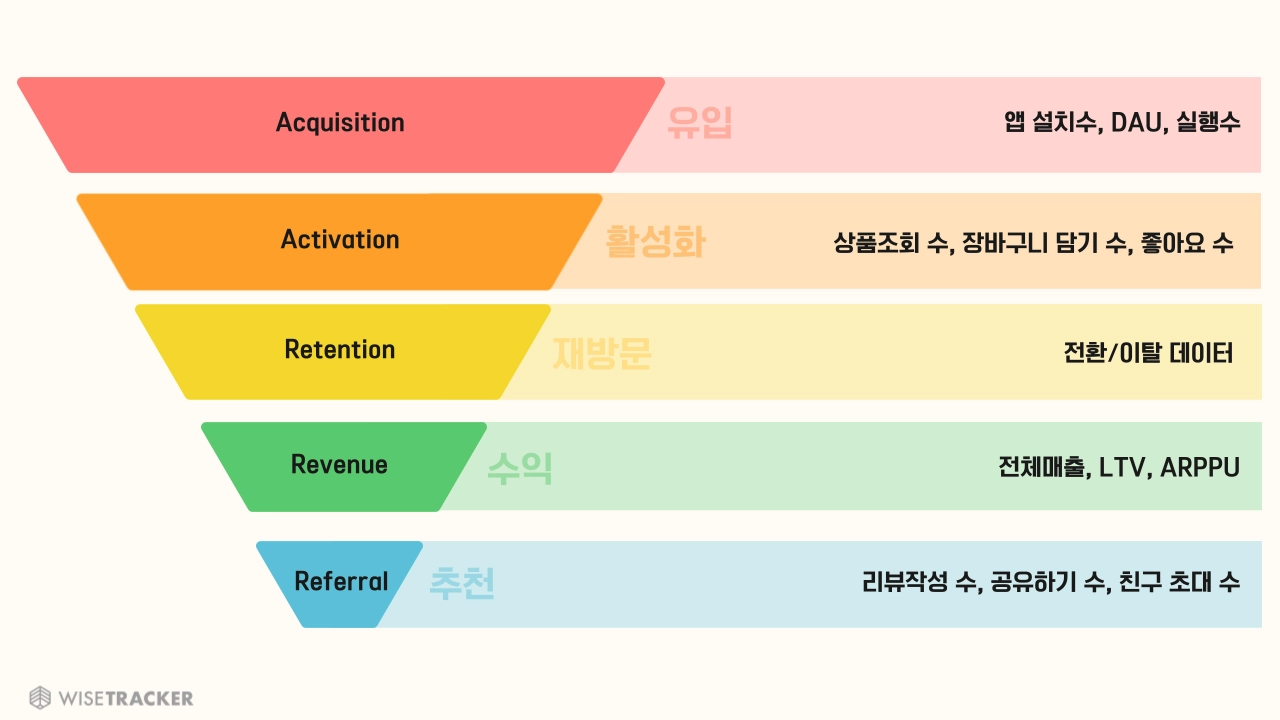  
    1. acquisition 사용자가 앱또는 사이트에 유입되는 과정. 광고나 검색엔진, 지인추천 등 굉장히 다양함. 신규 고객을 어떻게 획득하고 신규 고객을 어떻게 획득할지, 어디로부터 획득할지 고려.   
    2. activation  사용자가 앱에 첫방문하여 주요 기능을 직접 사용하는 것  
    3. retention 유지 단계. 신규 자를 장기사용자로 전환시키는 것에 초점을 맞춤. 고객의 지속적 구매 행위를 모색    
    4. revenue 사용자가 제품을 유료 구매하기로 결정한 단계. 최대한 소비를 늘려 매출을 늘리게끔 행위를 유도. 고객의 평생 가치를 지속적으로 높여나가고, 유치 비용은 줄여나가야함    
    5. referral 서비스에 만족한 고객이 타인에게 추천하는 단계. 제품의 지속적 성장을 위해 매우 중요한 단계.  

---

이하 지표를 분석하는 방법   

> 코호트 분석   

정의된 시간 범위 내에 공통된 특성을 공유하는 사용자 집단. 데이터 셋을 관련 그룹으로 묶는 행동 분석, 시간과 날짜에 기반하는 사용자 세그먼트를 분류. 주로 유지와 이탈을 체크하는데 많이 사용된다.    
    세로축은 코호트별 비교   
    대각선은 시점별 비교   
    가로축은 시간의 경과에 따른 변화 관찰   

> 퍼널 분석  

고객 여정. 유저 접속부터 떠날 때까지 추적함. 시간이 지날 수록 이탈하기에 점점 좁아짐. 유입률, 전환률을 높이고 퍼널 단계 자체의 순설르 뒤집거나 추가하는 식으로 개선 방안을 모색해볼 수 있다.   

>